# Laboratorio 5 – Modelo espacial de cobertura hospitalaria
**CC2017 Modelación y Simulación** · Estado de análisis: **Texas (TX, FIPS 48)**

**¿Por qué Texas?** Es el estado con más hospitales con datos de camas (591, muy por encima del mínimo de 50), tiene 254 condados que mezclan grandes áreas metropolitanas (Houston, Dallas, Austin, San Antonio) con extensas zonas rurales y de baja densidad en el oeste, lo que produce brechas de cobertura reales que analizar.

Este notebook cubre el **Task 1**, el **Task 2** y el **Task 3**. Las fuentes son los cuatro archivos provistos en Canvas:
`hospitales_eeuu.geojson`, `condados_eeuu.geojson`, `poblacion_condados.csv` y `estados_eeuu.geojson`.

### Fórmulas que usa el código
* **Población cubierta (1.3b):** `Pob_cubierta_i = Pob_i × Área(Condado_i ∩ Buffer) / Área(Condado_i)` (población uniforme dentro del condado).
* **Unión de cobertura (1.3a):** `C_r = ⋃_h B(h, r)` (`unary_union`).
* **Min-Max (2.2a):** `x_norm = (x − x_min) / (x_max − x_min)`.
* **Índice (2.2b):** `I = w1·C1 + w2·C2 + w3·C3`, con `Σ w_i = 1`.
* **MCLP voraz (2.3c):** en cada iteración se elige el candidato que maximiza la población adicional cubierta.
* **Task 3.1 (isocronas):** requiere `pip install osmnx networkx` y **conexión a internet** (descarga la red vial de OpenStreetMap).
* **Task 3.3 (sensibilidad y MCLP):** no requiere internet.

## Task 1.1 – Carga y preparación de datos

In [1]:
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib_scalebar.scalebar import ScaleBar
from pyproj import Proj
from scipy.stats import skew
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

# --- Parámetros del estado elegido ---
STATE = "TX"            # columna `estado` de hospitales y `codigo` de estados
STATE_FIPS = "48"       # columna `cod_estado` de condados (FIPS de 2 dígitos)
PROJ_CRS = "EPSG:3083"  # NAD83 / Texas Centric Albers Equal Area (justificado en 1.1d)

def north_arrow(ax, x=0.94, y=0.93):
    ax.annotate("N", xy=(x, y), xytext=(x, y - 0.09), xycoords="axes fraction", ha="center", fontsize=13,
                arrowprops=dict(arrowstyle="-|>", color="k", lw=2))

### 1.1a – Carga de los cuatro archivos

In [2]:
hosp_raw = gpd.read_file("hospitales_eeuu.geojson")
cond_raw = gpd.read_file("condados_eeuu.geojson")
est_raw  = gpd.read_file("estados_eeuu.geojson")
pob_raw  = pd.read_csv("poblacion_condados.csv")

archivos = {"hospitales_eeuu.geojson": hosp_raw, "condados_eeuu.geojson": cond_raw,
            "estados_eeuu.geojson": est_raw, "poblacion_condados.csv": pob_raw}
for nombre, df in archivos.items():
    crs = getattr(df, "crs", None)
    print(f"{nombre}\n  registros: {len(df):,} | CRS: {crs.to_string() if crs else 'no aplica (tabla)'}")
    print(f"  columnas : {list(df.columns)}\n")

hospitales_eeuu.geojson
  registros: 7,154 | CRS: EPSG:4326
  columnas : ['nombre', 'tipo', 'ciudad', 'estado', 'condado', 'fips_condado', 'camas_total', 'camas_icu', 'camas_licenciadas', 'ocupacion_total', 'ocupacion_icu', 'geometry']

condados_eeuu.geojson
  registros: 3,221 | CRS: EPSG:4326
  columnas : ['fips', 'nombre', 'cod_estado', 'geometry']

estados_eeuu.geojson
  registros: 51 | CRS: EPSG:4326
  columnas : ['nombre', 'codigo', 'pais', 'geometry']

poblacion_condados.csv
  registros: 3,246 | CRS: no aplica (tabla)
  columnas : ['fips', 'condado', 'estado', 'lat', 'lon', 'poblacion']



### 1.1b – Limpiezas sobre el dataset completo (antes de filtrar por estado)
* **Población:** se eliminan los registros con `fips ≥ 80000` (casos especiales, no son condados reales) y `fips` se convierte a *string* de 5 dígitos.
* **Hospitales:** se reporta el porcentaje de nulos en `camas_total` y se trabaja solo con hospitales con datos de camas.

In [3]:
# Población: quitar fips >= 80000 y normalizar a string de 5 dígitos
n0 = len(pob_raw)
pob = pob_raw[pob_raw["fips"] < 80000].copy()
pob["fips"] = pob["fips"].astype(str).str.zfill(5)
print(f"Población: {n0} registros → {len(pob)} tras eliminar {n0 - len(pob)} con FIPS ≥ 80000")

# Hospitales: porcentaje de nulos en camas_total y filtro
pct_nulos = hosp_raw["camas_total"].isna().mean() * 100
hosp_all = hosp_raw[hosp_raw["camas_total"].notna()].copy()
print(f"Hospitales: {pct_nulos:.2f} % con camas_total nulo ({hosp_raw['camas_total'].isna().sum()} de {len(hosp_raw)})")
print(f"Hospitales con datos de camas a nivel nacional: {len(hosp_all)}")

Población: 3246 registros → 3144 tras eliminar 102 con FIPS ≥ 80000
Hospitales: 15.24 % con camas_total nulo (1090 de 7154)
Hospitales con datos de camas a nivel nacional: 6064


### 1.1c – Filtro por estado y unión de población con la geometría de condados

In [4]:
hosp = hosp_all[hosp_all["estado"] == STATE].copy()
n_estado_total = (hosp_raw["estado"] == STATE).sum()
print(f"Hospitales de {STATE}: {n_estado_total} en total → {len(hosp)} con datos de camas tras la limpieza")

cond = cond_raw[cond_raw["cod_estado"] == STATE_FIPS].copy()
pob_estado = pob[pob["fips"].str[:2] == STATE_FIPS]
cond = cond.merge(pob_estado[["fips", "poblacion"]], on="fips", how="left")   # llave de unión: FIPS

print(f"Condados con geometría: {len(cond)} | condados con población: {len(pob_estado)} | unidos sin nulos: {cond['poblacion'].notna().sum()}")
assert set(cond["fips"]) == set(pob_estado["fips"]) and cond["poblacion"].notna().all(), "Los condados no coinciden"
print(f"Población total de {STATE}: {cond['poblacion'].sum():,.0f}")

estado = est_raw[est_raw["codigo"] == STATE].copy()

Hospitales de TX: 739 en total → 591 con datos de camas tras la limpieza
Condados con geometría: 254 | condados con población: 254 | unidos sin nulos: 254
Población total de TX: 28,995,881


### 1.1d – Reproyección
Las capas están en WGS84 (grados). Para medir distancias y áreas en metros se reproyectan a **EPSG:3083 (NAD83 / Texas Centric Albers Equal Area)**.

In [5]:
hosp_p = hosp.to_crs(PROJ_CRS)
cond_p = cond.to_crs(PROJ_CRS).set_index("fips")
estado_p = estado.to_crs(PROJ_CRS)
cond_p["area_km2"] = cond_p.geometry.area / 1e6

# Distorsión del CRS en las esquinas y el centro del estado (k = factor de escala lineal)
pr = Proj(PROJ_CRS); b = estado.total_bounds
pts = {"SO": (b[0], b[1]), "NO": (b[0], b[3]), "SE": (b[2], b[1]), "NE": (b[2], b[3]),
       "Centro": ((b[0] + b[2]) / 2, (b[1] + b[3]) / 2)}
f = {k: pr.get_factors(*v) for k, v in pts.items()}
print(pd.DataFrame({"k meridional": {k: v.meridional_scale for k, v in f.items()},
                    "k paralelo": {k: v.parallel_scale for k, v in f.items()},
                    "factor de área": {k: v.areal_scale for k, v in f.items()}}).round(5).to_string())

        k meridional  k paralelo  factor de área
SO           0.99782     1.00218             1.0
NO           0.99783     1.00218             1.0
SE           0.99782     1.00218             1.0
NE           0.99783     1.00218             1.0
Centro       1.00213     0.99787             1.0


**Justificación de EPSG:3083 (NAD83 / Texas Centric Albers Equal Area).**
* Es el sistema del *Texas Centric Mapping System*, diseñado para cubrir **todo el estado con una sola proyección**. UTM obligaría a partir Texas en las zonas 13, 14 y 15; y usar una sola zona (por ejemplo la 14N) daría un factor de escala de 1.006 (0.6 %) y un factor de área de 1.012 en el extremo oeste, casi tres veces la distorsión de Albers.
* Es una proyección **cónica de áreas iguales (Albers)** con paralelos estándar a 27.5° N y 35° N y meridiano central 100° O, ajustados a la extensión norte-sur del estado. Los factores de escala de la tabla muestran que la distorsión lineal queda en ≈ ±0.22 %, es decir ≈ 220 m por cada 100 km, o ≈ 55 m en el buffer más grande (25 km) y ≈ 110 m en el de 50 km.
* **Conserva el área** (factor de área = 1.0000 en toda la tabla). Esto es especialmente conveniente para este laboratorio, porque la fórmula de la población cubierta usa cocientes de áreas `Área(Condado ∩ Buffer) / Área(Condado)`, que así resultan exactos bajo el supuesto de población uniforme.
* La alternativa conforme (EPSG:3081, Lambert) tiene la misma distorsión lineal, pero deforma las áreas hasta ≈ 0.4 %. Por eso se prefirió Albers.

### 1.1e – Mapa base (tres capas)

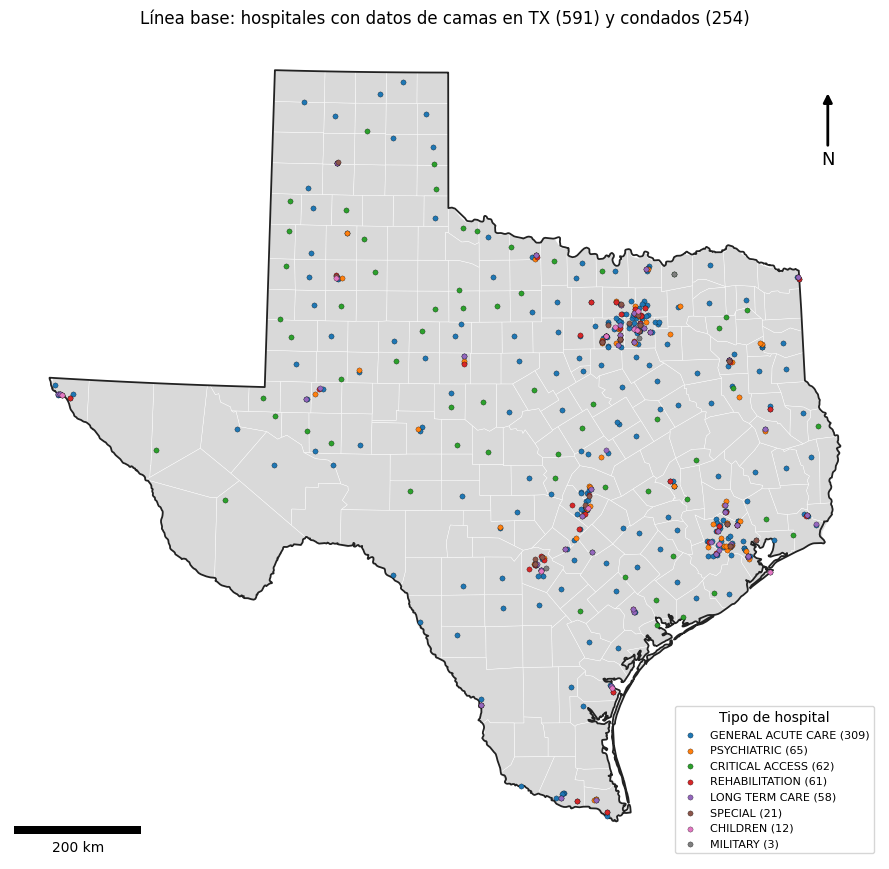

In [6]:
tipos = hosp_p["tipo"].value_counts()
colores = dict(zip(tipos.index, plt.cm.tab10.colors))
fig, ax = plt.subplots(figsize=(9, 9))
cond_p.plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.3)
for t in tipos.index:
    s = hosp_p[hosp_p["tipo"] == t]
    ax.scatter(s.geometry.x, s.geometry.y, s=14, color=colores[t], label=f"{t} ({len(s)})", zorder=3, edgecolor="k", linewidth=0.2)
estado_p.boundary.plot(ax=ax, color="#222", linewidth=1.3)
ax.add_artist(ScaleBar(1, "m", length_fraction=0.25, location="lower left")); north_arrow(ax)
ax.legend(title="Tipo de hospital", loc="lower right", fontsize=8)
ax.set_title(f"Línea base: hospitales con datos de camas en {STATE} ({len(hosp_p)}) y condados ({len(cond_p)})")
ax.set_axis_off(); plt.tight_layout(); plt.savefig(FIG / "mapa_base.png", dpi=150); plt.show()

## Task 1.2 – Estadísticas por condado
Los hospitales se asignan a su condado con la columna `fips_condado`. Antes de usarla se comprueba que coincide con la ubicación espacial del punto.

In [7]:
# Verificación: ¿el condado indicado por fips_condado coincide con el condado que contiene el punto?
chk = gpd.sjoin(hosp_p[["fips_condado", "geometry"]], cond_p.reset_index()[["fips", "geometry"]], predicate="within", how="left")
chk = chk[~chk.index.duplicated()]
print(f"Hospitales cuyo fips_condado coincide con el polígono que los contiene: {(chk['fips_condado'] == chk['fips']).mean()*100:.1f} %")

agg = hosp_p.groupby("fips_condado").agg(n_hospitales=("nombre", "size"),
                                         camas_total=("camas_total", "sum"),
                                         camas_uci=("camas_icu", "sum"))      # sum ignora NaN en camas UCI
tabla = cond_p[["nombre", "poblacion"]].join(agg).fillna({"n_hospitales": 0, "camas_total": 0, "camas_uci": 0})
tabla["camas_x_10k"] = tabla["camas_total"] / tabla["poblacion"] * 1e4        # camas totales por 10,000 hab.
tabla["uci_x_10k"] = tabla["camas_uci"] / tabla["poblacion"] * 1e4            # camas UCI por 10,000 hab.
tabla[["n_hospitales", "camas_total", "camas_uci"]] = tabla[["n_hospitales", "camas_total", "camas_uci"]].astype(int)
print(f"Condados: {len(tabla)} | sin hospitales: {(tabla['n_hospitales'] == 0).sum()} | suma de camas: {tabla['camas_total'].sum():,}")
display(tabla.sort_values("poblacion", ascending=False).round(2))

Hospitales cuyo fips_condado coincide con el polígono que los contiene: 98.6 %
Condados: 254 | sin hospitales: 77 | suma de camas: 72,752


,nombre,poblacion,n_hospitales,camas_total,camas_uci,camas_x_10k,uci_x_10k
fips,,,,,,,
48201,Harris,4713325.0,61,13411,1242,28.45,2.64
48113,Dallas,2635516.0,42,7459,613,28.30,2.33
48439,Tarrant,2102515.0,44,5612,461,26.69,2.19
48029,Bexar,2003554.0,27,6406,561,31.97,2.80
48453,Travis,1273954.0,22,3112,309,24.43,2.43
...,...,...,...,...,...,...,...
48311,McMullen,743.0,0,0,0,0.00,0.00
48033,Borden,654.0,0,0,0,0.00,0.00
48261,Kenedy,404.0,0,0,0,0.00,0.00


### 1.2a – Cinco condados con menos camas por habitante (población > 10,000)

In [8]:
grandes = tabla[tabla["poblacion"] > 10_000]
# Muchos condados tienen 0 camas (empate); se desempata por mayor población (más gente afectada)
menos = grandes.sort_values(["camas_x_10k", "poblacion"], ascending=[True, False]).head(5)
print(f"Condados con población > 10,000: {len(grandes)} | de ellos sin hospitales: {(grandes['camas_total'] == 0).sum()}")
display(menos[["nombre", "poblacion", "n_hospitales", "camas_total", "camas_x_10k", "uci_x_10k"]].round(2))

Condados con población > 10,000: 166 | de ellos sin hospitales: 31


,nombre,poblacion,n_hospitales,camas_total,camas_x_10k,uci_x_10k
fips,,,,,,
48381,Randall,137713.0,0,0,0.0,0.0
48361,Orange,83396.0,0,0,0.0,0.0
48409,San Patricio,66730.0,0,0,0.0,0.0
48199,Hardin,57602.0,0,0,0.0,0.0
48467,Van Zandt,56590.0,0,0,0.0,0.0


**Lectura.** Los cinco son condados **sin ningún hospital** con datos de camas (0 camas por 10,000 hab.), y con población considerable (57,000 a 138,000 habitantes). Hay 31 condados con más de 10,000 habitantes en la misma situación; se desempató por mayor población para listar primero a los más poblados.
"Cero camas en el condado" no significa "cero acceso": son condados de tamaño medio donde la población probablemente usa hospitales de condados vecinos. Esa distancia se mide en 2.1a.

### 1.2b – Cinco condados con mayor concentración de camas

In [9]:
mayor = tabla.sort_values("camas_x_10k", ascending=False).head(5).copy()
mayor["mayor_hospital_camas"] = [hosp_p[hosp_p["fips_condado"] == k]["camas_total"].max() for k in mayor.index]
mayor["poblacion_vecinos_50km"] = [
    cond_p.loc[(cond_p.index != k) & (cond_p.centroid.distance(cond_p.loc[k].geometry.centroid) <= 50_000), "poblacion"].sum()
    for k in mayor.index]
display(mayor[["nombre", "poblacion", "n_hospitales", "camas_total", "camas_x_10k", "mayor_hospital_camas", "poblacion_vecinos_50km"]].round(2))

,nombre,poblacion,n_hospitales,camas_total,camas_x_10k,mayor_hospital_camas,poblacion_vecinos_50km
fips,,,,,,,
48433,Stonewall,1350.0,1,20,148.15,20.0,6692.0
48197,Hardeman,3933.0,2,45,114.42,24.0,1155.0
48447,Throckmorton,1501.0,1,14,93.27,14.0,27177.0
48147,Fannin,35514.0,2,317,89.26,292.0,5331.0
48483,Wheeler,5056.0,2,41,81.09,25.0,28625.0


**¿Ventaja de acceso o artefacto?** En su mayoría es un **artefacto del denominador**, no una ventaja real:
* Cuatro de los cinco (Stonewall, Hardeman, Throckmorton y Wheeler) son condados rurales con entre 1,350 y 5,056 habitantes. Uno o dos hospitales pequeños (14 a 45 camas en total, típicos de hospitales de acceso crítico) bastan para dar 81 a 148 camas por 10,000 habitantes, simplemente porque la población es diminuta. Eso no implica más servicios: un hospital de 20 camas no tiene la complejidad de los hospitales de una ciudad, aunque su razón de camas por habitante sea mayor.
* Esos hospitales atienden también a los habitantes de los condados vecinos, que a su vez no tienen hospital. La tabla muestra cuánta población vive a ≤ 50 km de cada uno.
* **Fannin** (35,514 hab.) es distinto: su mayor hospital tiene 292 camas, y entre sus dos hospitales está el *Sam Rayburn Memorial Veterans Center* (tipo `MILITARY`, 292 camas), un hospital de veteranos que atiende una región amplia y no solo al condado. Es un caso claro de hospital regional que infla el indicador.
En conjunto, las camas por habitante **a nivel condado** mezclan capacidad real con tamaño de población y con flujos entre condados, y por eso conviene complementarlas con medidas de distancia (como se hace en 2.1 y 2.2).

### 1.2c – Distribuciones

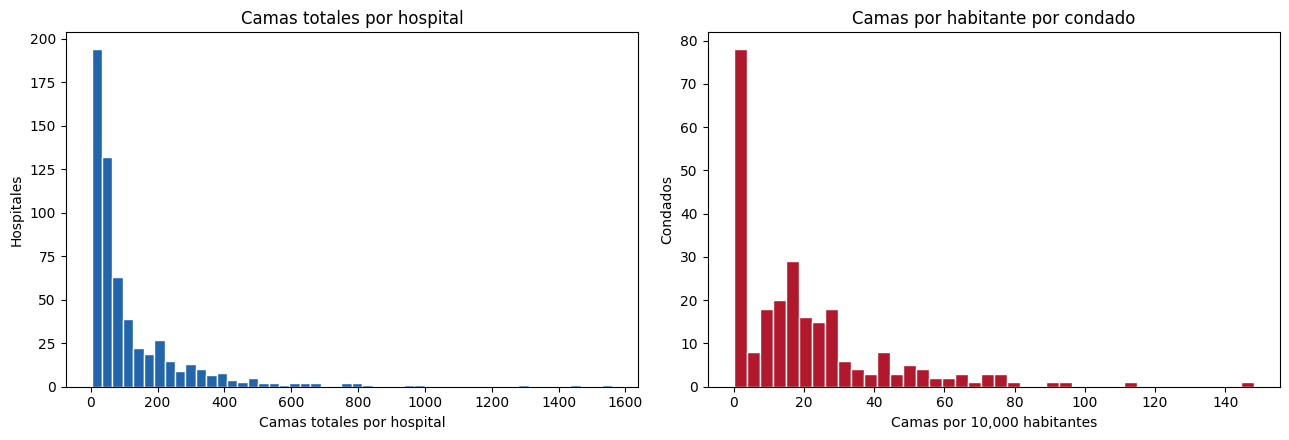

camas por hospital         media   123.1 | mediana    54.0 | máx   1560.0 | asimetría  3.67
camas x 10k por condado    media    19.7 | mediana    15.0 | máx    148.1 | asimetría  1.90
Condados con 0 camas: 77 de 254 (30 %)


In [10]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
axs[0].hist(hosp_p["camas_total"], bins=50, color="#2166ac", edgecolor="white")
axs[0].set_xlabel("Camas totales por hospital"); axs[0].set_ylabel("Hospitales"); axs[0].set_title("Camas totales por hospital")
axs[1].hist(tabla["camas_x_10k"], bins=40, color="#b2182b", edgecolor="white")
axs[1].set_xlabel("Camas por 10,000 habitantes"); axs[1].set_ylabel("Condados"); axs[1].set_title("Camas por habitante por condado")
plt.tight_layout(); plt.savefig(FIG / "histogramas.png", dpi=150); plt.show()

for nombre, s in [("camas por hospital", hosp_p["camas_total"]), ("camas x 10k por condado", tabla["camas_x_10k"])]:
    print(f"{nombre:26s} media {s.mean():7.1f} | mediana {s.median():7.1f} | máx {s.max():8.1f} | asimetría {skew(s):5.2f}")
print(f"Condados con 0 camas: {(tabla['camas_total'] == 0).sum()} de {len(tabla)} ({(tabla['camas_total'] == 0).mean()*100:.0f} %)")

**Interpretación de las distribuciones.**
* **Camas por hospital:** muy **asimétrica a la derecha** (asimetría 3.67). La mayoría de hospitales son pequeños (mediana 54 camas; 392 de 591 tienen menos de 100) y una cola larga llega hasta 1,560 camas, con una media (123) más del doble que la mediana. Pocos hospitales muy grandes concentran gran parte de la capacidad.
* **Camas por 10,000 hab. por condado:** también asimétrica (1.90) y con un **pico en cero**: 77 de 254 condados (30 %) no tienen ningún hospital con camas. De los 177 condados con camas, 121 están entre 5 y 30, y hay valores extremos de hasta 148 que corresponden a condados diminutos (ver 1.2b).
* **Implicaciones para la cobertura:** (i) la media no es representativa, por lo que conviene usar medianas o percentiles; (ii) los condados con cero camas hacen que las razones por habitante estén indefinidas o saturadas (afecta a C2 del índice en 2.2); (iii) un buffer cuenta igual a un hospital de 3 camas que a uno de 1,560, de modo que la cobertura por distancia **sobrestima la cobertura efectiva de capacidad**; (iv) los valores extremos pueden dominar cualquier promedio sin transformar.

## Task 1.3 – Buffers de cobertura

### 1.3a – Buffers y unión
`C_r = ⋃_h B(h, r)` para r ∈ {10, 25, 50} km, usando las capas en metros.

In [11]:
RADII = [10, 25, 50]
cobertura = {r: hosp_p.buffer(r * 1000).union_all() for r in RADII}      # unary_union de los buffers del mismo radio
for r in RADII:
    print(f"r = {r:>2} km → área de cobertura unificada: {cobertura[r].area / 1e6:,.0f} km² (área del estado: {estado_p.area.iloc[0] / 1e6:,.0f} km²)")

r = 10 km → área de cobertura unificada: 83,209 km² (área del estado: 685,340 km²)
r = 25 km → área de cobertura unificada: 363,435 km² (área del estado: 685,340 km²)
r = 50 km → área de cobertura unificada: 667,115 km² (área del estado: 685,340 km²)


### 1.3b – Población cubierta
`Pob_cubierta_i = Pob_i × Área(Condado_i ∩ Buffer) / Área(Condado_i)`, con población uniforme dentro de cada condado.

In [12]:
POP_TOTAL = cond_p["poblacion"].sum()
filas = []
for r in RADII:
    frac = shapely.area(shapely.intersection(cond_p.geometry.values, cobertura[r])) / cond_p.geometry.area.values   # fracción de área cubierta
    cond_p[f"frac_{r}"] = np.clip(frac, 0, 1)
    cond_p[f"cub_{r}"] = cond_p["poblacion"] * cond_p[f"frac_{r}"]
    filas.append({"radio_km": r, "población_cubierta_estimada": cond_p[f"cub_{r}"].sum(),
                  "población_total": POP_TOTAL, "porcentaje_cobertura": 100 * cond_p[f"cub_{r}"].sum() / POP_TOTAL})
tabla_cob = pd.DataFrame(filas)
display(tabla_cob.round(2))

,radio_km,población_cubierta_estimada,población_total,porcentaje_cobertura
0,10,13652044.58,28995881.0,47.08
1,25,25312722.30,28995881.0,87.30
2,50,28698734.86,28995881.0,98.98


**Lectura.** Un buffer de 10 km cubre al 47 % de la población, uno de 25 km al 87 % y uno de 50 km al 99 %. La cobertura por **población** crece mucho más rápido que la cobertura por **área** (a 25 km se cubre el 87 % de la gente pero solo ≈ 51 % del territorio del estado), porque la población se concentra en las áreas metropolitanas, donde hay muchos hospitales.

### 1.3c – Mapa de cobertura a 25 km

estado_cob
Parcialmente cubierto     233
No cubierto                13
Completamente cubierto      8


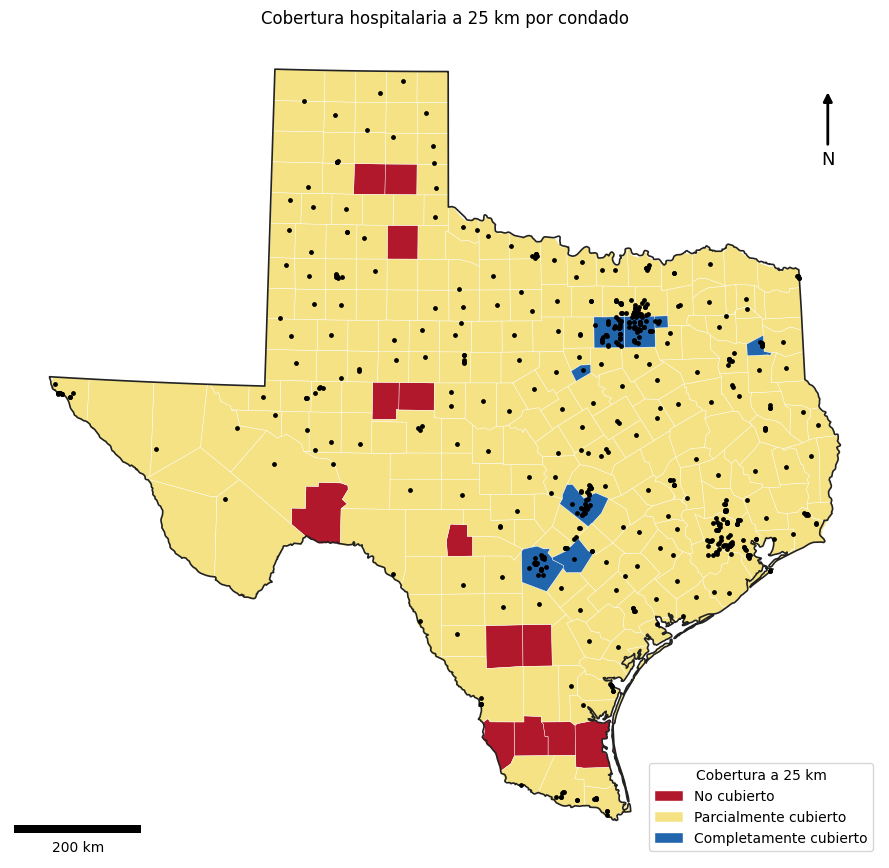

In [13]:
frac25 = cond_p["frac_25"]
cond_p["estado_cob"] = pd.Categorical(
    np.select([frac25 >= 0.999, frac25 > 1e-6], ["Completamente cubierto", "Parcialmente cubierto"], "No cubierto"),
    ["No cubierto", "Parcialmente cubierto", "Completamente cubierto"])
print(cond_p["estado_cob"].value_counts().to_string())

cmap = ListedColormap(["#b2182b", "#f4e285", "#2166ac"])        # divergente: rojo (sin cobertura) – amarillo – azul
fig, ax = plt.subplots(figsize=(9, 9))
cond_p.plot(column="estado_cob", cmap=cmap, categorical=True, legend=True, ax=ax, edgecolor="white", linewidth=0.3,
            legend_kwds={"loc": "lower right", "title": "Cobertura a 25 km"})
estado_p.boundary.plot(ax=ax, color="#222", linewidth=1.2)
ax.scatter(hosp_p.geometry.x, hosp_p.geometry.y, s=6, color="k", zorder=3, label="Hospitales")
ax.add_artist(ScaleBar(1, "m", length_fraction=0.25, location="lower left")); north_arrow(ax)
ax.set_title("Cobertura hospitalaria a 25 km por condado")
ax.set_axis_off(); plt.tight_layout(); plt.savefig(FIG / "cobertura_25km.png", dpi=150); plt.show()

## Task 2.1 – Sensibilidad del análisis de distancia

### 2.1a – Distancia del centroide de cada condado al hospital más cercano

In [14]:
cent = cond_p.geometry.centroid                                    # punto de referencia de cada condado
dist = {}
for fips, pt in cent.items():
    d = hosp_p.geometry.distance(pt)                               # distancias (m) a todos los hospitales
    dist[fips] = (d.min() / 1000, d.idxmin())                      # km y hospital más cercano
cond_p["dist_km"] = pd.Series({k: v[0] for k, v in dist.items()})
cond_p["hosp_cercano"] = pd.Series({k: v[1] for k, v in dist.items()})

top10_dist = cond_p.sort_values("dist_km", ascending=False).head(10)
display(top10_dist[["nombre", "poblacion", "dist_km"]].round(1))

,nombre,poblacion,dist_km
fips,,,
48443,Terrell,776.0,78.6
48247,Jim Hogg,5200.0,75.5
48043,Brewster,9203.0,75.4
48137,Edwards,1932.0,71.9
48229,Hudspeth,4886.0,69.8
48377,Presidio,6704.0,69.4
48385,Real,3452.0,68.4
48505,Zapata,14179.0,66.3
48261,Kenedy,404.0,65.2


**Lectura.** Los diez condados más alejados están a entre 65 y 79 km de su hospital más cercano y son **muy poco poblados** (de 404 a 14,179 habitantes). Se concentran en dos zonas: el sur del estado, hacia la frontera con México (Jim Hogg, Zapata, Kenedy, McMullen), y el oeste y suroeste (Terrell, Edwards, Real, Brewster, Presidio, Hudspeth), junto con Oldham en el *Panhandle*. Son zonas de ranchos y desierto con densidades muy bajas. Como la distancia se mide desde el centroide, es una aproximación: la población real puede estar más cerca del hospital si se concentra en un pueblo cercano a él.

### 2.1b – Curva de cobertura acumulada (5–100 km)

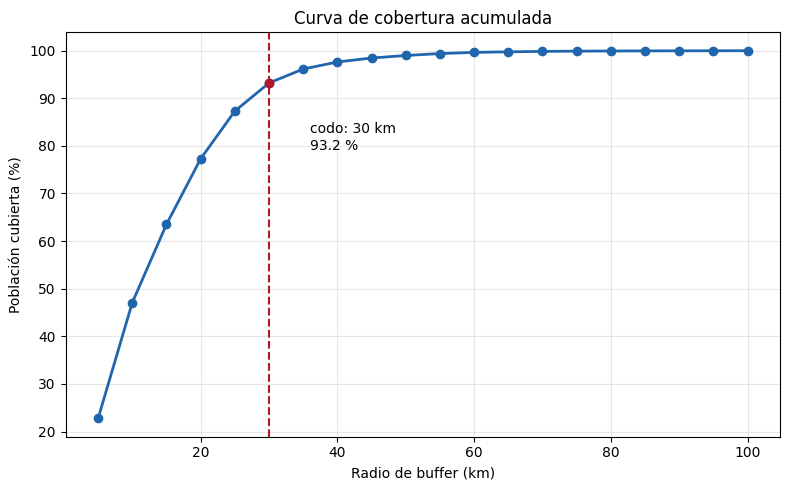

radio_km,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100
cobertura_%,22.77,47.08,63.51,77.28,87.30,93.2,96.13,97.61,98.44,98.98,99.37,99.63,99.74,99.83,99.89,99.92,99.94,99.96,99.97,99.98
ganancia_pp,NaN,24.31,16.43,13.77,10.02,5.9,2.93,1.48,0.83,0.53,0.40,0.25,0.12,0.09,0.05,0.03,0.02,0.02,0.01,0.01


Punto de inflexión: 30 km → 93.2 % de la población cubierta


In [15]:
radios = np.arange(5, 105, 5)
areas = cond_p.geometry.area.values
pct = []
for r in radios:
    cov = hosp_p.buffer(r * 1000).union_all()
    frac = np.clip(shapely.area(shapely.intersection(cond_p.geometry.values, cov)) / areas, 0, 1)
    pct.append(100 * (cond_p["poblacion"].values * frac).sum() / POP_TOTAL)
pct = np.array(pct)

# Punto de inflexión (método del codo / Kneedle): máxima separación entre la curva normalizada y la diagonal
xn = (radios - radios.min()) / (radios.max() - radios.min())
yn = (pct - pct.min()) / (pct.max() - pct.min())
i_knee = int(np.argmax(yn - xn)); r_knee = radios[i_knee]
ganancia = np.diff(pct, prepend=np.nan)                                       # puntos porcentuales por cada paso de 5 km

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(radios, pct, "o-", lw=2, color="#2166ac")
ax.axvline(r_knee, ls="--", color="#b2182b"); ax.scatter([r_knee], [pct[i_knee]], color="#b2182b", zorder=3)
ax.annotate(f"codo: {r_knee} km\n{pct[i_knee]:.1f} %", (r_knee, pct[i_knee]), xytext=(r_knee + 6, pct[i_knee] - 14))
ax.set_xlabel("Radio de buffer (km)"); ax.set_ylabel("Población cubierta (%)"); ax.grid(alpha=0.3)
ax.set_title("Curva de cobertura acumulada"); plt.tight_layout(); plt.savefig(FIG / "curva_cobertura.png", dpi=150); plt.show()
display(pd.DataFrame({"radio_km": radios, "cobertura_%": pct.round(2), "ganancia_pp": np.round(ganancia, 2)}).set_index("radio_km").T)
print(f"Punto de inflexión: {r_knee} km → {pct[i_knee]:.1f} % de la población cubierta")

**Punto de inflexión: ≈ 30 km (93.2 % de la población cubierta).** Hasta ese radio cada 5 km adicionales suman entre 24 y 6 puntos porcentuales; después de 30 km suman menos de 3 puntos por paso, y pasados 50 km, menos de 0.5.

**Qué significa para la política de acceso hospitalario en Texas:**
* La red actual de hospitales ya llega a ≈ 93 % de la población dentro de 30 km, es decir, ≈ 30 a 40 minutos por carretera. Es decir, el problema no es la cobertura general.
* El ≈ 7 % restante (≈ 2 millones de personas) vive en zonas de muy baja densidad. Para alcanzarlo con hospitales fijos habría que ampliar el radio mucho (cada punto porcentual adicional exige construir en lugares casi vacíos), con un costo por persona muy alto.
* Por tanto, ampliar la cobertura de las zonas remotas requiere **otro tipo de intervención** (transporte de emergencia y aéreo, telemedicina, clínicas móviles, hospitales de acceso crítico bien equipados) y no más hospitales convencionales.
* Es una lectura de **cobertura por distancia en línea recta**: no dice nada sobre la capacidad ni sobre el tiempo real de viaje (Task 3).

*Nota:* el punto exacto del codo depende del rango analizado (5–100 km); con otro rango máximo se desplazaría ligeramente, pero la conclusión (rendimientos fuertemente decrecientes a partir de ≈ 30 km) no cambia.

### 2.1c – Tipo de hospital más cercano a los cinco condados más alejados

In [16]:
top5 = top10_dist.head(5)
cerc = hosp_p.loc[top5["hosp_cercano"]]
res = pd.DataFrame({"condado": top5["nombre"].values, "dist_km": top5["dist_km"].values,
                    "hospital_cercano": cerc["nombre"].values, "tipo": cerc["tipo"].values,
                    "camas_total": cerc["camas_total"].values, "camas_uci": cerc["camas_icu"].values})
display(res.round(1))
print(f"Camas promedio del hospital más cercano (5 condados más alejados): {res['camas_total'].mean():.0f} | "
      f"mediana: {res['camas_total'].median():.0f}")
print(f"Referencia estatal → media: {hosp_p['camas_total'].mean():.0f} | mediana: {hosp_p['camas_total'].median():.0f}")
print("Distribución de tipos en el estado (%):"); print((hosp_p["tipo"].value_counts(normalize=True) * 100).round(1).to_string())

,condado,dist_km,hospital_cercano,tipo,camas_total,camas_uci
0,Terrell,78.6,IRAAN GENERAL HOSPITAL,GENERAL ACUTE CARE,14.0,NaN
1,Jim Hogg,75.5,STARR COUNTY MEMORIAL HOSPITAL,GENERAL ACUTE CARE,48.0,NaN
2,Brewster,75.4,BIG BEND REGIONAL MEDICAL CENTER,CRITICAL ACCESS,25.0,3.0
3,Edwards,71.9,LILLIAN M. HUDSPETH MEMORIAL HOSPITAL,CRITICAL ACCESS,12.0,NaN
4,Hudspeth,69.8,CULBERSON HOSPITAL,CRITICAL ACCESS,14.0,NaN


Camas promedio del hospital más cercano (5 condados más alejados): 23 | mediana: 14
Referencia estatal → media: 123 | mediana: 54
Distribución de tipos en el estado (%):
tipo
GENERAL ACUTE CARE    52.3
PSYCHIATRIC           11.0
CRITICAL ACCESS       10.5
REHABILITATION        10.3
LONG TERM CARE         9.8
SPECIAL                3.6
CHILDREN               2.0
MILITARY               0.5


**¿Los condados más alejados tienden a estar cerca de hospitales pequeños?** Sí, con los datos de estos cinco condados:
* Los hospitales más cercanos tienen entre 12 y 48 camas, con una **media de 23 y una mediana de 14**, contra una media de 123 y una mediana de 54 en todo el estado.
* Tres de los cinco son hospitales de **acceso crítico** (*Critical Access*), una designación federal para hospitales rurales de hasta 25 camas, y los otros dos son hospitales generales de solo 14 y 48 camas.
* Solo uno (Big Bend Regional Medical Center) reporta camas UCI (3); los otros cuatro no reportan ninguna.

Es decir, los condados más alejados están lejos y, además, lo que tienen cerca es un hospital pequeño con servicios limitados. La brecha de acceso es doble: distancia y capacidad. Debemos tener cuidado con la conclusión porque la muestra es de solo cinco condados.

## Task 2.2 – Índice compuesto de vulnerabilidad de acceso hospitalario
* **C1** = distancia del centroide al hospital más cercano (km).
* **C2** = inverso de las camas totales por habitante (`habitantes / camas`). Para condados sin hospitales se asigna el valor máximo antes de normalizar.
* **C3** = tasa de ocupación promedio (`ocupacion_total`) de los hospitales a ≤ 50 km del centroide del condado. Si no hay ninguno con dato de ocupación, se asigna el valor máximo.

In [17]:
idx = cond_p.index
camas_pc = tabla.loc[idx, "camas_total"] / tabla.loc[idx, "poblacion"]                 # camas por habitante
c2_raw = (1 / camas_pc.replace(0, np.nan))                                              # inverso: habitantes por cama
c2_raw = c2_raw.fillna(c2_raw.max())                                                    # sin hospitales → valor máximo

occ = []
for fips, pt in cent.items():
    cerca = hosp_p[(hosp_p.geometry.distance(pt) <= 50_000) & hosp_p["ocupacion_total"].notna()]
    occ.append(cerca["ocupacion_total"].mean() if len(cerca) else np.nan)
c3_raw = pd.Series(occ, index=idx)
n_sin_occ = c3_raw.isna().sum()
c3_raw = c3_raw.fillna(c3_raw.max())                                                    # sin hospitales a 50 km → valor máximo

comp = pd.DataFrame({"c1_raw": cond_p["dist_km"], "c2_raw": c2_raw, "c3_raw": c3_raw})
minmax = lambda s: (s - s.min()) / (s.max() - s.min())                                  # x_norm = (x - x_min)/(x_max - x_min)
for k in ("c1", "c2", "c3"):
    comp[k] = minmax(comp[f"{k}_raw"])
print(f"Condados sin hospitales con ocupación a 50 km (se asigna el máximo): {n_sin_occ} | condados sin hospitales: {(camas_pc == 0).sum()}")
display(comp.describe().round(3))
print("Asimetría de cada componente crudo:", {k: round(float(skew(comp[f'{k}_raw'])), 2) for k in ('c1', 'c2', 'c3')})

Condados sin hospitales con ocupación a 50 km (se asigna el máximo): 22 | condados sin hospitales: 77


,c1_raw,c2_raw,c3_raw,c1,c2,c3
count,254.000,254.000,254.000,254.000,254.000,254.000
mean,20.661,1325.447,0.392,0.260,0.423,0.529
std,19.097,1191.722,0.193,0.244,0.401,0.291
min,0.270,67.500,0.040,0.000,0.000,0.000
25%,5.210,364.311,0.220,0.063,0.100,0.270
50%,14.149,668.244,0.420,0.177,0.202,0.571
75%,32.204,3038.040,0.554,0.408,1.000,0.771
max,78.621,3038.040,0.706,1.000,1.000,1.000


Asimetría de cada componente crudo: {'c1': 1.11, 'c2': 0.63, 'c3': -0.05}


### 2.2a – Justificación de la normalización min-max
`x_norm = (x − x_min)/(x_max − x_min)` es una transformación afín creciente, por lo que:
1. **Conserva el orden y las proporciones relativas** entre condados: no altera el ranking dentro de cada componente.
2. **Lleva las tres variables al mismo rango [0, 1] y las vuelve adimensionales** (km, habitantes por cama y fracción de ocupación), lo que permite promediarlas de manera coherente.
3. Es **interpretable**: 0 = condado con menor vulnerabilidad en ese componente y 1 = el de mayor vulnerabilidad.

**Cuándo puede no ser apropiada:**
* Es **sensible a valores atípicos**, porque depende solo de los extremos. En este índice el caso es claro en C2: el inverso de las camas per cápita tiene una cola muy larga (condados con muy pocas camas dan valores enormes) y, además, se asigna el máximo a los condados sin hospitales; esos extremos comprimen al resto de condados cerca de 0. En esos casos conviene *winsorizar*, aplicar un logaritmo o usar normalización por rangos (percentiles).
* Los extremos dependen de la muestra: el índice **no es comparable entre estados o años**.
* Supone una relación **lineal** entre el componente y la vulnerabilidad, aunque la realidad puede tener umbrales (por ejemplo, más de 30 minutos de viaje a un hospital agudo).

### 2.2b – Pesos del índice

| Componente | Peso | Argumento |
|---|---|---|
| C1 – distancia al hospital más cercano | **w₁ = 0.40** | La distancia es la barrera de acceso más directa y la menos sustituible: en emergencias (infarto, trauma, partos) el tiempo hasta el hospital determina el resultado clínico, y ninguna cantidad de camas lejanas lo compensa. |
| C2 – inverso de camas per cápita | **w₂ = 0.35** | Mide la capacidad instalada disponible por persona. Es casi tan importante como la distancia, pero se pondera algo menos porque las camas de un condado también atienden a pacientes de condados vecinos (ver 1.2b), de modo que sobreestima la capacidad local en condados con hospitales regionales. |
| C3 – ocupación promedio a 50 km | **w₃ = 0.25** | Una ocupación alta indica poca capacidad de absorber demanda, pero es una medida instantánea y volátil (varía por temporada y reporte), con datos faltantes y valores superiores a 100 %. Por eso recibe el menor peso. |

Los pesos suman 1. El análisis de sensibilidad frente a otros pesos corresponde al Task 3.3.

In [18]:
W = {"c1": 0.40, "c2": 0.35, "c3": 0.25}
assert abs(sum(W.values()) - 1) < 1e-9
comp["indice"] = sum(w * comp[c] for c, w in W.items())          # I = w1*C1 + w2*C2 + w3*C3
cond_p["indice"] = comp["indice"]
top10 = cond_p.sort_values("indice", ascending=False).head(10)
t = top10[["nombre", "poblacion", "dist_km", "indice"]].join(comp[["c2_raw", "c3_raw"]])
t["camas_total"] = tabla.loc[t.index, "camas_total"]
display(t[["nombre", "poblacion", "camas_total", "dist_km", "c2_raw", "c3_raw", "indice"]].round(3))

,nombre,poblacion,camas_total,dist_km,c2_raw,c3_raw,indice
fips,,,,,,,
48443,Terrell,776.0,0,78.621,3038.04,0.706,1.000
48247,Jim Hogg,5200.0,0,75.456,3038.04,0.706,0.984
48137,Edwards,1932.0,0,71.884,3038.04,0.706,0.966
48229,Hudspeth,4886.0,0,69.800,3038.04,0.706,0.955
48377,Presidio,6704.0,0,69.397,3038.04,0.706,0.953
48385,Real,3452.0,0,68.365,3038.04,0.706,0.948
48505,Zapata,14179.0,0,66.348,3038.04,0.706,0.937
48261,Kenedy,404.0,0,65.165,3038.04,0.706,0.931
48359,Oldham,2112.0,0,65.019,3038.04,0.706,0.931


**Lectura del top 10.** Los diez condados más vulnerables (Terrell, Jim Hogg, Edwards, Hudspeth, Presidio, Real, Zapata, Kenedy, Oldham y McMullen) coinciden en nueve de diez con los más alejados del 2.1a (Brewster, el tercero más lejano, sí tiene un hospital de 25 camas, así que su C2 no es máximo y sale del top 10; entra McMullen). Todos están a más de 64 km de un hospital, no tienen camas y no tienen ningún hospital con dato de ocupación a 50 km, por lo que **C2 y C3 toman el valor máximo (1.0) en los diez**. Dos consecuencias:
* Dentro de este grupo el orden lo decide solo C1 (la distancia).
* El índice **satura**: 77 condados sin hospitales reciben C2 = 1 y 22 reciben C3 = 1, de modo que esos componentes distinguen entre "tiene hospital" y "no tiene" pero no entre condados sin hospitales. Esto limita la capacidad del índice para priorizar y debe tenerse en cuenta en el análisis de sensibilidad (Task 3.3).

### 2.2c – Mapa del índice por quintiles

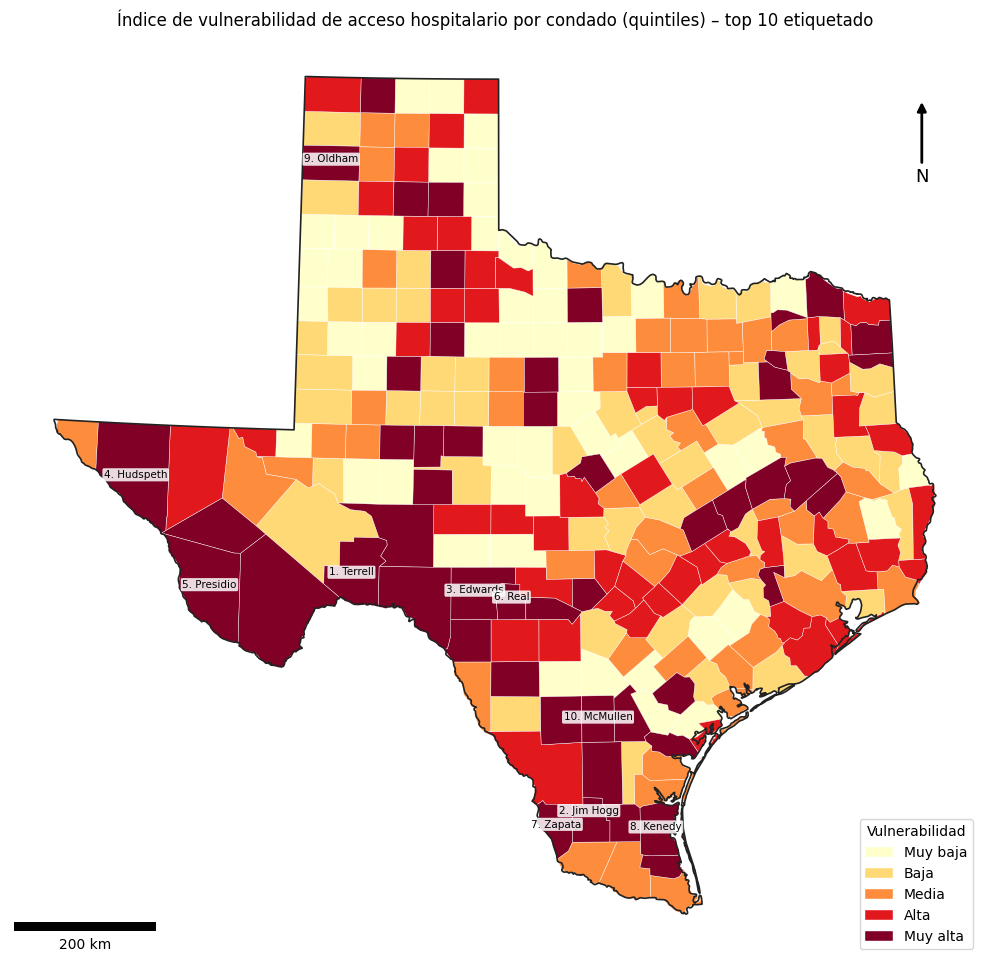

In [19]:
etiquetas = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
cond_p["categoria"] = pd.qcut(cond_p["indice"].rank(method="first"), 5, labels=etiquetas)
fig, ax = plt.subplots(figsize=(10, 10))
cond_p.plot(column="categoria", cmap="YlOrRd", categorical=True, legend=True, ax=ax, edgecolor="white", linewidth=0.3,
            legend_kwds={"loc": "lower right", "title": "Vulnerabilidad"})
estado_p.boundary.plot(ax=ax, color="#222", linewidth=1.2)
for k, (fips, r) in enumerate(top10.iterrows(), 1):
    pt = r.geometry.representative_point()
    ax.annotate(f"{k}. {r['nombre']}", (pt.x, pt.y), fontsize=7.5, ha="center", zorder=5,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
ax.add_artist(ScaleBar(1, "m", length_fraction=0.25, location="lower left")); north_arrow(ax)
ax.set_title("Índice de vulnerabilidad de acceso hospitalario por condado (quintiles) – top 10 etiquetado")
ax.set_axis_off(); plt.tight_layout(); plt.savefig(FIG / "indice_vulnerabilidad.png", dpi=150); plt.show()

## Task 2.3 – MCLP simplificado (algoritmo voraz)
Se busca maximizar la población cubierta `Σ_i Pob_i · fracción_cubierta_i` eligiendo 3 sitios entre los candidatos. Como el modelo asume población uniforme en el condado, la **ganancia** de un candidato es
`Σ_i Pob_i × Área((Condado_i ∖ Cobertura_actual) ∩ Buffer_25km) / Área(Condado_i)`.

### 2.3a – Grilla de candidatos (50 km)

In [20]:
STEP, R = 50_000, 25_000
estado_geom = estado_p.geometry.iloc[0]
minx, miny, maxx, maxy = estado_p.total_bounds
gx, gy = np.meshgrid(np.arange(minx, maxx + STEP, STEP), np.arange(miny, maxy + STEP, STEP))
dentro = shapely.contains_xy(estado_geom, gx.ravel(), gy.ravel())             # intersección espacial con el límite estatal
cand = np.c_[gx.ravel()[dentro], gy.ravel()[dentro]]
print(f"Puntos de la grilla: {gx.size} | candidatos dentro de {STATE}: {len(cand)}")

Puntos de la grilla: 650 | candidatos dentro de TX: 271


### 2.3b – Población adicional por candidato (25 km)
Se parte de la porción de cada condado **sin cobertura actual** (a 25 km). La ganancia de cada candidato es la población proporcional al área sin cobertura que cae dentro de su buffer.

In [21]:
pop = cond_p["poblacion"].values
area = cond_p.geometry.area.values
unc = gpd.GeoSeries(shapely.difference(cond_p.geometry.values, cobertura[25]), crs=PROJ_CRS)   # zona sin cobertura de cada condado

def ganancia(buf, unc):
    """Población adicional cubierta por un buffer: Σ Pob_i · Área(unc_i ∩ buf) / Área(Condado_i)."""
    ii = unc.sindex.query(buf, predicate="intersects")
    return float((pop[ii] * shapely.area(shapely.intersection(unc.values[ii], buf)) / area[ii]).sum()) if len(ii) else 0.0

buffers = [shapely.Point(x, y).buffer(R) for x, y in cand]
gain0 = np.array([ganancia(b, unc) for b in buffers])
base_pct = tabla_cob.loc[tabla_cob["radio_km"] == 25, "porcentaje_cobertura"].iloc[0]
print(f"Cobertura actual a 25 km: {base_pct:.2f} % | población sin cobertura: {POP_TOTAL * (1 - base_pct / 100):,.0f}")
print(f"Ganancia individual: máx {gain0.max():,.0f} | mediana {np.median(gain0):,.0f} | candidatos con ganancia 0: {(gain0 == 0).sum()}")

Cobertura actual a 25 km: 87.30 % | población sin cobertura: 3,683,159
Ganancia individual: máx 179,382 | mediana 3,612 | candidatos con ganancia 0: 7


### 2.3c – Selección voraz de 3 nuevos hospitales

,iteración,x,y,pob_adicional,pob_adicional_acum,cobertura_total_%
0,1,1672107.17,6962447.22,179381.71,179381.71,87.92
1,2,922107.17,7512447.22,137429.37,316811.08,88.39
2,3,1922107.17,7262447.22,86763.89,403574.98,88.69


Cobertura a 25 km: 87.30 % → 88.69 % tras agregar 3 hospitales (+403,575 personas)
Sitios propuestos en los condados: ['Hidalgo', 'El Paso', 'Fort Bend']


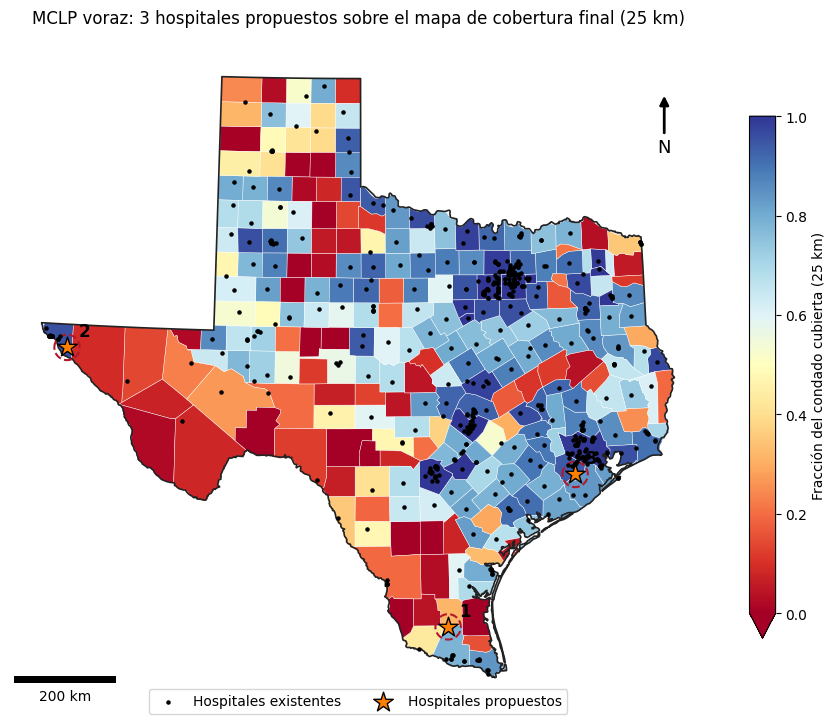

In [22]:
P = 3
unc_i = unc.copy()                                  # mapa de cobertura que se va actualizando
elegidos, filas, acum = [], [], 0.0
for it in range(1, P + 1):
    g = np.array([ganancia(b, unc_i) if k not in elegidos else -1 for k, b in enumerate(buffers)])
    k = int(np.argmax(g)); elegidos.append(k); acum += g[k]
    ii = unc_i.sindex.query(buffers[k], predicate="intersects")
    vals = unc_i.values.copy(); vals[ii] = shapely.difference(vals[ii], buffers[k])      # actualizar cobertura
    unc_i = gpd.GeoSeries(vals, crs=PROJ_CRS)
    filas.append({"iteración": it, "x": cand[k, 0], "y": cand[k, 1], "pob_adicional": g[k], "pob_adicional_acum": acum,
                  "cobertura_total_%": base_pct + 100 * acum / POP_TOTAL})
res_mclp = pd.DataFrame(filas)
display(res_mclp.round(2))
print(f"Cobertura a 25 km: {base_pct:.2f} % → {res_mclp['cobertura_total_%'].iloc[-1]:.2f} % tras agregar {P} hospitales "
      f"(+{res_mclp['pob_adicional_acum'].iloc[-1]:,.0f} personas)")

# Condado donde cae cada sitio propuesto
sel = gpd.GeoDataFrame(geometry=gpd.points_from_xy(cand[elegidos, 0], cand[elegidos, 1]), crs=PROJ_CRS)
sel["condado"] = [cond_p.loc[cond_p.contains(p), "nombre"].iloc[0] for p in sel.geometry]
print("Sitios propuestos en los condados:", sel["condado"].tolist())

cond_p["frac_final"] = 1 - shapely.area(unc_i.values) / area
fig, ax = plt.subplots(figsize=(9, 9))
cond_p.plot(column="frac_final", cmap="RdYlBu", vmin=0, vmax=1, ax=ax, edgecolor="white", linewidth=0.3,
            legend=True, legend_kwds={"label": "Fracción del condado cubierta (25 km)", "shrink": 0.6})
estado_p.boundary.plot(ax=ax, color="#222", linewidth=1.2)
gpd.GeoSeries(sel.buffer(R)).boundary.plot(ax=ax, color="#b2182b", linewidth=1.5, linestyle="--")
ax.scatter(hosp_p.geometry.x, hosp_p.geometry.y, s=5, color="k", zorder=3, label="Hospitales existentes")
ax.scatter(sel.geometry.x, sel.geometry.y, s=220, marker="*", color="#ff7f00", edgecolor="k", zorder=5, label="Hospitales propuestos")
for k, p in enumerate(sel.geometry, 1):
    ax.annotate(str(k), (p.x, p.y), xytext=(8, 8), textcoords="offset points", fontsize=12, weight="bold")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2); ax.add_artist(ScaleBar(1, "m", length_fraction=0.25, location="lower left")); north_arrow(ax)
ax.set_title("MCLP voraz: 3 hospitales propuestos sobre el mapa de cobertura final (25 km)")
ax.set_axis_off(); plt.tight_layout(); plt.savefig(FIG / "mclp_voraz.png", dpi=150); plt.show()

**Lectura.** El algoritmo propone sitios en los condados de **Hidalgo** (valle del Río Grande, +179,382 personas), **El Paso** (+137,429) y **Fort Bend** (área de Houston, +86,764). Juntos cubren a 403,575 personas más y suben la cobertura a 25 km de 87.30 % a 88.69 % (+1.39 puntos). Las ganancias decrecen (179 mil, 137 mil, 87 mil), como es de esperar: cada elección cubre lo más rentable que queda.

* La mejora es pequeña porque el 87 % ya está cubierto y los ≈ 3.7 millones restantes están dispersos en muchos condados parcialmente cubiertos (233 de 254) que 3 buffers de 25 km no pueden alcanzar.
* **Advertencia del modelo:** al asumir población uniforme dentro del condado, la parte "sin cobertura" de condados grandes y densos (Hidalgo, El Paso, Fort Bend) se supone tan poblada como el resto, aunque en la realidad la gente vive en las ciudades, donde ya hay hospitales. Por eso el modelo probablemente **sobrestima** la población adicional que cubrirían estos sitios y favorece a condados muy poblados frente a las zonas rurales remotas, que quedan sin elegir aunque tengan los mayores déficits de distancia.
* Los candidatos están limitados a una grilla de 50 km, por lo que los sitios son aproximados y no ubicaciones exactas.

## Task 3.1 – Buffer circular vs. isocrona de tiempo de viaje
Se compara la cobertura con **buffer de 25 km** y con **isocrona de 30 min en vehículo** (red vial de OSMnx) para los hospitales que atienden a los tres condados más vulnerables del índice del Task 2.2.

**Decisión de interpretación.** Terrell, Jim Hogg y Edwards **no tienen ningún hospital** (por eso C2 = máximo), así que se usa **el hospital más cercano a cada uno** (`hosp_cercano`, Task 2.1a).

**Supuestos.** Velocidad de flujo libre por tipo de vía (tabla `SPEEDS`), sin congestión; isocrona calculada *desde* el hospital; población uniforme por condado (igual que 1.3b). Primero la celda de imports (las celdas 3.1·5 a 3.1·8 usan internet y pueden tardar varios minutos).

In [ ]:
import itertools, networkx as nx, osmnx as ox
from shapely.geometry import LineString, Polygon
from shapely.ops import substring
from matplotlib.patches import Circle
from scipy.stats import spearmanr, kendalltau
from pathlib import Path

CACHE = Path("osm_cache"); CACHE.mkdir(exist_ok=True)   # caché de las redes viales descargadas
ox.settings.use_cache = True; ox.settings.requests_timeout = 600   # Overpass puede tardar

### 3.1·1 – Hospitales objetivo

In [ ]:
t3 = cond_p.sort_values("indice", ascending=False).head(3)
objetivo = pd.DataFrame({
    "condado": t3["nombre"].values, "pob_condado": t3["poblacion"].values, "dist_centroide_km": t3["dist_km"].round(1).values,
    "hospital": hosp_p.loc[t3["hosp_cercano"], "nombre"].values, "tipo": hosp_p.loc[t3["hosp_cercano"], "tipo"].values,
    "camas": hosp_p.loc[t3["hosp_cercano"], "camas_total"].values}, index=t3.index)
HOSP = hosp_p.loc[t3["hosp_cercano"]].copy(); HOSP.index = t3.index          # un hospital por condado objetivo
display(objetivo)
estado_geom = estado_p.geometry.iloc[0]

### 3.1·2 – Lado buffer: círculo de 25 km
Las **áreas** se recortan al límite de Texas (el círculo de Rio Grande City cruza el Río Grande hacia México); la **población** usa la geometría sin recortar porque solo suma lo que cae en polígonos de condados de Texas.

In [ ]:
CNT_GEOM, CNT_POP, CNT_AREA = cond_p.geometry.values, cond_p["poblacion"].values, cond_p.geometry.area.values
def pob_cubierta(geom):
    return float((CNT_POP * np.clip(shapely.area(shapely.intersection(CNT_GEOM, geom)) / CNT_AREA, 0, 1)).sum())
km2 = lambda g: g.area / 1e6

BUF = {k: h.geometry.buffer(25_000) for k, h in HOSP.iterrows()}             # círculos de 25 km (metros, EPSG:3083)
for k in BUF:
    print(f"{objetivo.loc[k,'hospital']:40s} círculo: {km2(BUF[k]):,.0f} km² | dentro de TX: {km2(BUF[k].intersection(estado_geom)):,.0f} km² "
          f"({100*BUF[k].intersection(estado_geom).area/BUF[k].area:.1f} %) | población: {pob_cubierta(BUF[k]):,.0f}")

### 3.1·3 – Velocidades por tipo de vía y descarga de la red

In [ ]:
SPEEDS = {"motorway": 110, "motorway_link": 60, "trunk": 100, "trunk_link": 55, "primary": 90, "primary_link": 50,
          "secondary": 80, "secondary_link": 45, "tertiary": 65, "tertiary_link": 40, "unclassified": 50,
          "residential": 40, "living_street": 20, "road": 40}
FALLBACK = 50
DIST_DESCARGA_M = 65_000       # caja de 130 km por lado: a 30 min y 120 km/h el alcance máximo es 60 km
ISO_MIN, ISO_BUF_M = 30, 1_000  # umbral de la isocrona (min) y ancho de acceso lateral alrededor de las vías (m)
HUECO_MAX_KM2 = 50              

def velocidad(hwy):
    hwy = hwy if isinstance(hwy, list) else [hwy]
    return float(np.mean([SPEEDS.get(h, FALLBACK) for h in hwy]))

def preparar_grafo(G):
    """Proyecta a EPSG:3083 y asigna velocidad y tiempo de viaje (s) por tipo de vía, ignorando el tag maxspeed."""
    Gp = ox.project_graph(G, to_crs=PROJ_CRS)
    for u, v, k, d in Gp.edges(keys=True, data=True):
        d["speed_kph"] = velocidad(d.get("highway"))
        d["travel_time"] = d["length"] / (d["speed_kph"] * 1000 / 3600)
    return Gp

def descargar(clave, geom_pt):
    f = CACHE / f"red_{clave}.graphml"
    if f.exists():
        return ox.load_graphml(f)
    lon, lat = gpd.GeoSeries([geom_pt], crs=PROJ_CRS).to_crs(4326).iloc[0].coords[0]
    G = ox.graph_from_point((lat, lon), dist=DIST_DESCARGA_M, dist_type="bbox", network_type="drive", simplify=True)
    ox.save_graphml(G, f); return G

### 3.1·4 – Isocrona con recorte de aristas parciales
En el oeste de Texas los cruces están separados por decenas de km; cada arista que se agota a mitad de camino se recorta en el punto exacto (`shapely.ops.substring`) en lugar de descartarse.

In [ ]:
def isocrona(Gp, nodo, minutos, buf_m=ISO_BUF_M):
    T = minutos * 60
    t = nx.single_source_dijkstra_path_length(Gp, nodo, cutoff=T, weight="travel_time")   # tiempo mínimo desde el hospital (s)
    lineas = []
    for u, tu in t.items():
        for _, v, d in Gp.out_edges(u, data=True):
            g = d.get("geometry") or LineString([(Gp.nodes[u]["x"], Gp.nodes[u]["y"]), (Gp.nodes[v]["x"], Gp.nodes[v]["y"])])
            if Point_u_lejos(g, Gp.nodes[u]): g = LineString(list(g.coords)[::-1])        # asegurar orientación u→v
            if tu + d["travel_time"] <= T: lineas.append(g)                                # arista completa
            else: lineas.append(substring(g, 0, (T - tu) / d["travel_time"], normalized=True))   # tramo parcial
    return rellenar(shapely.union_all(lineas).buffer(buf_m)), t

def rellenar(g, max_m2=HUECO_MAX_KM2 * 1e6):
    """Rellena huecos pequeños (manzanas entre vías alcanzadas); conserva los grandes (p. ej. un parque sin vías)."""
    from shapely.geometry import Polygon
    ps = [g] if g.geom_type == "Polygon" else list(g.geoms)
    return shapely.union_all([Polygon(p.exterior, [h for h in p.interiors if Polygon(h).area > max_m2]) for p in ps])

def Point_u_lejos(g, nu):
    c = list(g.coords); pu = np.array([nu["x"], nu["y"]])
    return np.hypot(*(np.array(c[0]) - pu)) > np.hypot(*(np.array(c[-1]) - pu))

### 3.1·5 – Descarga, snapping e isocrona de cada hospital (usa internet)

In [ ]:
REDES, ISO, SNAP = {}, {}, {}
for k, h in HOSP.iterrows():
    G = descargar(k, h.geometry); Gp = preparar_grafo(G); REDES[k] = Gp
    nodo = ox.distance.nearest_nodes(Gp, X=h.geometry.x, Y=h.geometry.y)
    SNAP[k] = np.hypot(Gp.nodes[nodo]["x"] - h.geometry.x, Gp.nodes[nodo]["y"] - h.geometry.y)
    iso, t = isocrona(Gp, nodo, ISO_MIN); ISO[k] = (iso, nodo, t)
    alcance = max(np.hypot(Gp.nodes[n]["x"] - h.geometry.x, Gp.nodes[n]["y"] - h.geometry.y) for n in t) / 1000
    print(f"{objetivo.loc[k,'hospital']:40s} aristas: {Gp.number_of_edges():,} | distancia hospital→nodo: {SNAP[k]:.0f} m | "
          f"nodos alcanzados: {len(t):,} | alcance máx. en línea recta: {alcance:.1f} km (descarga cubre {DIST_DESCARGA_M/1000:.0f} km)")
    assert alcance < 0.95 * DIST_DESCARGA_M / 1000, "La isocrona toca el borde de la red descargada: aumente DIST_DESCARGA_M"

### 3.1·6 – Resultado 3.1a: diferencia entre cobertura con buffer y con isocrona

In [ ]:
filas = []
for k in HOSP.index:
    b = BUF[k].intersection(estado_geom); i = ISO[k][0].intersection(estado_geom)
    cond_obj = cond_p.loc[k, "geometry"]
    filas.append({"hospital": objetivo.loc[k, "hospital"], "condado_objetivo": objetivo.loc[k, "condado"],
        "área_buffer_km2": km2(b), "área_isocrona_km2": km2(i), "área_solo_buffer_km2": km2(b.difference(i)), "área_solo_isocrona_km2": km2(i.difference(b)),
        "jaccard": b.intersection(i).area / b.union(i).area,
        "pob_buffer": pob_cubierta(BUF[k]), "pob_isocrona": pob_cubierta(ISO[k][0]),
        "%_cond_objetivo_buffer": 100 * b.intersection(cond_obj).area / cond_obj.area, "%_cond_objetivo_isocrona": 100 * i.intersection(cond_obj).area / cond_obj.area})
res_31 = pd.DataFrame(filas)
ub = shapely.union_all([BUF[k] for k in BUF]).intersection(estado_geom); ui = shapely.union_all([ISO[k][0] for k in ISO]).intersection(estado_geom)
res_31.loc[len(res_31)] = {"hospital": "UNIÓN de los 3", "condado_objetivo": "-", "área_buffer_km2": km2(ub), "área_isocrona_km2": km2(ui),
    "área_solo_buffer_km2": km2(ub.difference(ui)), "área_solo_isocrona_km2": km2(ui.difference(ub)), "jaccard": ub.intersection(ui).area / ub.union(ui).area,
    "pob_buffer": pob_cubierta(shapely.union_all(list(BUF.values()))), "pob_isocrona": pob_cubierta(shapely.union_all([ISO[k][0] for k in ISO])), "%_cond_objetivo_buffer": np.nan, "%_cond_objetivo_isocrona": np.nan}
res_31["Δ_pob (buffer − isocrona)"] = res_31["pob_buffer"] - res_31["pob_isocrona"]
res_31["Δ_pob_%_de_la_isocrona"] = 100 * res_31["Δ_pob (buffer − isocrona)"] / res_31["pob_isocrona"]
res_31["Δ_área_%"] = 100 * (res_31["área_buffer_km2"] - res_31["área_isocrona_km2"]) / res_31["área_isocrona_km2"]
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
display(res_31.round(2).T)
res_31.round(3).to_csv("resultados_3_1a.csv", index=False)

### 3.1·7 – Sensibilidad a las velocidades asumidas (±20 %)
Cambiar todas las velocidades en ±20 % equivale a cambiar el umbral a 37.5 min o 25 min con las velocidades base.

In [ ]:
sens = []
for factor, minutos in [("velocidades −20 %", 37.5), ("base", 30), ("velocidades +20 %", 25)]:
    fila = {"escenario": factor}
    for k in HOSP.index:
        iso, _ = isocrona(REDES[k], ISO[k][1], minutos)
        fila[objetivo.loc[k, "condado"]] = pob_cubierta(iso)
    isos = shapely.union_all([isocrona(REDES[k], ISO[k][1], minutos)[0] for k in HOSP.index])
    fila["unión 3 hospitales"] = pob_cubierta(isos); fila["área unión km2 (en TX)"] = km2(isos.intersection(estado_geom)); sens.append(fila)
display(pd.DataFrame(sens).round(0)); print("Referencia buffer 25 km: unión =", f"{pob_cubierta(shapely.union_all(list(BUF.values()))):,.0f} personas, {km2(ub):,.0f} km²")

### 3.1·8 – Mapa comparativo

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6.4))
for ax, k in zip(axs, HOSP.index):
    h = HOSP.loc[k]; Gp = REDES[k]
    c0 = cond_p[cond_p.geometry.distance(h.geometry) < 80_000]
    c0.plot(ax=ax, color="#f2f2f2", edgecolor="#bbb", linewidth=0.5)
    cond_p.loc[[k]].plot(ax=ax, color="#fdd0a2", edgecolor="#d94801", linewidth=1.2)
    ox.graph_to_gdfs(Gp, nodes=False).plot(ax=ax, color="#9e9e9e", linewidth=0.4, zorder=2)
    gpd.GeoSeries([ISO[k][0]], crs=PROJ_CRS).plot(ax=ax, color="#2166ac", alpha=0.35, zorder=3)
    gpd.GeoSeries([ISO[k][0]], crs=PROJ_CRS).boundary.plot(ax=ax, color="#2166ac", linewidth=1.5, zorder=4)
    gpd.GeoSeries([BUF[k]], crs=PROJ_CRS).boundary.plot(ax=ax, color="#b2182b", linewidth=1.6, linestyle="--", zorder=4)
    ax.scatter(h.geometry.x, h.geometry.y, marker="*", s=260, color="#ff7f00", edgecolor="k", zorder=6)
    ax.set_xlim(h.geometry.x - 75_000, h.geometry.x + 75_000); ax.set_ylim(h.geometry.y - 75_000, h.geometry.y + 75_000)
    ax.set_title(f"{objetivo.loc[k,'hospital'].title()}\n(condado objetivo: {objetivo.loc[k,'condado']})", fontsize=10); ax.set_axis_off()
axs[0].plot([], [], "--", color="#b2182b", label="Buffer 25 km"); axs[0].fill_between([], [], color="#2166ac", alpha=0.35, label="Isocrona 30 min")
axs[0].legend(loc="lower left", fontsize=9)
plt.suptitle("Buffer circular de 25 km vs. isocrona de 30 min (red vial OSM)", y=1.02); plt.tight_layout()
plt.savefig(FIG / "isocronas_vs_buffer.png", dpi=150, bbox_inches="tight"); plt.show()

**Lectura 3.1 (completar con la salida de arriba).**
* El buffer de 25 km cubre **0 %** de los tres condados objetivo: la distancia mínima del hospital al polígono del condado es 29.0 km (Terrell), 45.3 km (Jim Hogg) y 30.5 km (Edwards).
* El círculo de Starr County es medio círculo: el hospital está a ~1 km del Río Grande y solo ~56 % del círculo cae en Texas.
* Con velocidad máxima de 110 km/h, la isocrona de 30 min no puede pasar de 55 km en línea recta; para tocar Jim Hogg haría falta una velocidad efectiva ≥ 90.6 km/h por toda la ruta.
* **Diferencia buffer − isocrona (población, unión de los 3):** *(completar)*  ·  **rango con ±20 % de velocidad:** *(completar)*
* **¿En qué direcciones la isocrona supera / queda por debajo del círculo?** *(completar según el mapa)*

## Task 3.3 – Reflexión metodológica
### 3.3a – Sensibilidad del índice de vulnerabilidad a los pesos
`I = w₁·C1 + w₂·C2 + w₃·C3`, `Σ wᵢ = 1`. Se evalúan **seis configuraciones** de pesos y, además, **20,000 vectores de pesos** muestreados uniformemente del símplex (Dirichlet(1,1,1)), que cubren todas las combinaciones posibles. Métricas: coincidencia del top 10, τ de Kendall dentro del top 10, ρ de Spearman del ranking completo y condados que cambian de quintil.

In [ ]:
nom = cond_p["nombre"]; C = comp[["c1", "c2", "c3"]].values
CFG = {"Base (0.40/0.35/0.25)": (0.40, 0.35, 0.25), "Equitativa (1/3 c/u)": (1/3, 1/3, 1/3),
       "Distancia dominante (0.60/0.25/0.15)": (0.60, 0.25, 0.15), "Capacidad dominante (0.20/0.60/0.20)": (0.20, 0.60, 0.20),
       "Ocupación dominante (0.20/0.20/0.60)": (0.20, 0.20, 0.60), "Sin ocupación (0.50/0.50/0)": (0.50, 0.50, 0.0)}
score = {k: pd.Series(C @ np.array(w), index=comp.index) for k, w in CFG.items()}
rank = {k: s.rank(ascending=False, method="first") for k, s in score.items()}
kb = "Base (0.40/0.35/0.25)"; top_base = list(rank[kb].sort_values().index[:10])
quint = lambda s: pd.qcut(s.rank(method="first"), 5, labels=False)
rows = []
for k in CFG:
    top = list(rank[k].sort_values().index[:10])
    rows.append({"configuración": k, "coinciden top10": len(set(top) & set(top_base)),
                 "coinciden top20": len(set(rank[k].sort_values().index[:20]) & set(rank[kb].sort_values().index[:20])),
                 "τ Kendall (orden top10)": kendalltau(rank[kb][top_base], rank[k][top_base])[0],
                 "ρ Spearman (ranking completo)": spearmanr(rank[kb], rank[k])[0],
                 "condados que cambian de quintil": int((quint(score[k]) != quint(score[kb])).sum()),
                 "…en ≥2 quintiles": int((abs(quint(score[k]) - quint(score[kb])) >= 2).sum()),
                 "entran al top10": [nom[f] for f in top if f not in top_base], "salen del top10": [nom[f] for f in top_base if f not in top]})
display(pd.DataFrame(rows).round(3))
T = pd.DataFrame({k: rank[k][top_base].astype(int) for k in CFG}); T.index = [nom[f] for f in top_base]
print("Posición de los 10 condados más vulnerables (base) en cada configuración:"); display(T)

#### Monte Carlo sobre todo el espacio de pesos

In [ ]:
# Monte Carlo sobre TODO el símplex de pesos
rng = np.random.default_rng(2026); N = 20_000
Wm = rng.dirichlet([1, 1, 1], N); S = Wm @ C.T
orden = np.argsort(-S, axis=1)[:, :10]
freq = pd.Series(np.bincount(orden.ravel(), minlength=len(comp)) / N, index=comp.index)
tabla_f = pd.DataFrame({"condado": nom, "frecuencia_en_top10": freq, "c1_raw_km": comp["c1_raw"], "C2": comp["c2"], "C3": comp["c3"]}).sort_values("frecuencia_en_top10", ascending=False).head(12)
display(tabla_f.round(3))
base_ord = np.array([comp.index.get_loc(f) for f in top_base])
print(f"Top 9 idéntico y en el mismo orden en {np.mean([(o[:9] == base_ord[:9]).all() for o in orden])*100:.1f} % de los {N:,} vectores de pesos")
print(f"Top 10 idéntico y en el mismo orden en {np.mean([(o == base_ord).all() for o in orden])*100:.1f} %")
print(f"Los mismos 9 condados (en cualquier orden) en el top 10 en {np.mean([len(set(o) & set(base_ord[:9])) == 9 for o in orden])*100:.1f} %")
print(f"Los 3 primeros (Terrell, Jim Hogg, Edwards) siguen siendo los 3 primeros en {np.mean([set(o[:3]) == set(base_ord[:3]) for o in orden])*100:.1f} %")

#### ¿Por qué es tan estable? (saturación de C2 y C3)

In [ ]:
# ¿Por qué es tan estable? Los 10 condados tienen C2 = C3 = 1 (saturados): solo C1 los distingue
sat = comp[(comp["c2"] == 1) & (comp["c3"] == 1)]
print(f"Condados con C2 = C3 = 1: {len(sat)}; todos a ≥ {sat['c1_raw'].min():.0f} km del hospital más cercano")
print("¿Los 10 de la base están entre ellos?:", all(f in sat.index for f in top_base))
# Único competidor: Brewster (C1 mayor que McMullen pero C2 muy menor). Entra solo si w1*Δ1 > w2*|Δ2|
bw, mc = comp.loc["48043"], comp.loc["48311"]
d = (bw[["c1", "c2", "c3"]] - mc[["c1", "c2", "c3"]]).values; print("Brewster − McMullen (ΔC1, ΔC2, ΔC3):", d.round(3), "→ Brewster supera a McMullen solo si w1/w2 >", round(abs(d[1]) / d[0], 2))
print(f"Población total de los 10 condados más vulnerables: {cond_p.loc[top_base, 'poblacion'].sum():,.0f} ({100*cond_p.loc[top_base, 'poblacion'].sum()/POP_TOTAL:.2f} % de Texas)")
# Prueba estructural extra: normalización por percentiles en lugar de min-max (pesos base)
pr = comp[["c1_raw", "c2_raw", "c3_raw"]].rank(pct=True) @ np.array([0.40, 0.35, 0.25])
print("Top 10 con normalización por percentiles:", [nom[f] for f in pr.sort_values(ascending=False).index[:10]])
print("ρ de Spearman índice base vs percentiles:", round(spearmanr(comp["indice"], pr)[0], 3))

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
t = tabla_f.head(11); col = ["#b2182b" if f >= 0.999 else "#fdae61" for f in t["frecuencia_en_top10"]]
axs[0].barh(t["condado"][::-1], 100 * t["frecuencia_en_top10"][::-1], color=col[::-1]); axs[0].set_xlabel("% de los 20,000 vectores de pesos en que el condado está en el top 10")
axs[0].set_title("Estabilidad del top 10 en todo el espacio de pesos"); axs[0].set_xlim(0, 105)
Rdf = pd.DataFrame(rows).iloc[1:]; etq = [s.split(" (")[0] for s in Rdf["configuración"]]
ax2 = axs[1]; ax2.bar(etq, Rdf["condados que cambian de quintil"], color="#2166ac"); ax2.set_ylabel("Condados que cambian de quintil (de 254)")
ax2.set_title("…pero el resto del mapa sí se mueve"); ax2.tick_params(axis="x", rotation=25)
for x, (n, r) in enumerate(zip(Rdf["condados que cambian de quintil"], Rdf["ρ Spearman (ranking completo)"])): ax2.text(x, n + 2, f"ρ={r:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "sensibilidad_pesos.png", dpi=150); plt.show()

**Lectura 3.3a.**
* **El top 10 no cambia** en ninguna de las seis configuraciones (mismos diez condados, mismo orden, τ = 1). Con 20,000 vectores de pesos, los mismos 9 condados aparecen siempre; el décimo lo ocupa McMullen el 86.3 % y Brewster el 13.7 % (Brewster supera a McMullen solo si w₁/w₂ > 6.5).
* **La estabilidad es en buena parte mecánica:** los diez condados tienen C2 = C3 = 1 (saturados), así que solo C1 (distancia) los distingue. La robustez del top 10 no prueba que los pesos sean correctos.
* **El resto del mapa sí cambia:** según la configuración, entre 18 y 128 de los 254 condados cambian de quintil (hasta 20 se mueven ≥ 2 quintiles). La categorización por quintiles no es robusta; el componente más inestable es C3 (ocupación).
* Los diez condados suman solo ~40 mil personas (0.14 % de Texas): un criterio basado en población afectada ordenaría distinto.

### 3.3b – Caso adverso del algoritmo voraz (MCLP)
La cobertura `f(S) = Σ wᵢ·1[i cubierto por S]` es monótona y submodular, por lo que el voraz garantiza `f(voraz) ≥ (1 − (1 − 1/P)ᴾ)·f(óptimo) ≥ (1 − 1/e)·f(óptimo) ≈ 0.632·f(óptimo)` (Nemhauser, Wolsey y Fisher, 1978); para P = 2 la garantía es 3/4.

**Instancia adversa mínima (1-D, R = 0.9):** cuatro focos de demanda en x = −2, −0.5, +0.5, +2 con pesos 5, 5.5, 5.5, 5. Un sitio central cubre los dos focos del medio (11) y supera a cualquier sitio lateral (10.5), pero dos sitios laterales cubren los cuatro focos (21).

In [ ]:
X = np.array([-2.0, -0.5, 0.5, 2.0]); Wd = np.array([5.0, 5.5, 5.5, 5.0]); Rr = 0.9
cand1 = np.round(np.arange(-3, 3.01, 0.25), 2)
cubre = lambda s: np.abs(X - s) <= Rr + 1e-9
def val(sitios): return Wd[np.any([cubre(s) for s in sitios], axis=0)].sum()
# voraz (desempate: primer candidato)
elegidos = []
for _ in range(2):
    g = [val(elegidos + [s]) - val(elegidos) if s not in elegidos else -1 for s in cand1]; elegidos.append(cand1[int(np.argmax(g))])
opt = max(itertools.combinations(cand1, 2), key=lambda p: val(list(p)))
print(f"Voraz: sitios {elegidos} → cobertura {val(elegidos):.1f} | Óptimo (fuerza bruta): sitios {list(opt)} → {val(list(opt)):.1f} | razón = {val(elegidos)/val(list(opt)):.3f} (cota teórica P=2: 0.75)")
print("Límite cuando el peso de los focos centrales → 5⁺:", 15/20)

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(9, 7.2), sharex=True)
def panel(ax, sitios, color, titulo, total):
    ax.axhline(0, color="#999", lw=0.8)
    for x, w in zip(X, Wd): ax.scatter(x, 0, s=w * 130, color="#4d4d4d", zorder=4); ax.annotate(f"w={w:g}", (x, 0), xytext=(0, -26), textcoords="offset points", ha="center", fontsize=9)
    for k, s in enumerate(sitios):
        ax.add_patch(Circle((s, 0), Rr, fill=True, alpha=0.18, color=color[k], ec=color[k], lw=2, ls="--")); ax.scatter(s, 0, marker="*", s=330, color=color[k], edgecolor="k", zorder=6)
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-1.2, 1.2); ax.set_aspect("equal"); ax.set_yticks([]); ax.set_title(titulo + f"\nPoblación cubierta = {total:g}", fontsize=11, loc="left")
panel(axs[0], [0.0, -1.25], ["#ff7f00", "#ffbb78"], "(a) Voraz: 1.º sitio al centro (cubre 11); el 2.º solo puede sumar 5", 16)
panel(axs[1], [-1.25, 1.25], ["#2166ac", "#2166ac"], "(b) Óptimo: un sitio en cada flanco (cubre 10.5 + 10.5)", 21)
axs[1].set_xlabel("Posición (unidades del radio de cobertura R = 0.9)")
plt.suptitle("Caso adverso del MCLP voraz: razón voraz/óptimo = 16/21 ≈ 0.76 (→ 0.75 al límite)", y=1.0); plt.tight_layout()
plt.savefig(FIG / "mclp_caso_adverso.png", dpi=150, bbox_inches="tight"); plt.show()

#### Cota de calidad para la solución voraz de Texas (sin calcular el óptimo)
Por submodularidad, `f(S) ≤ Σ_{s∈S} f({s})`: el óptimo con P = 3 no puede superar la suma de las **tres mayores ganancias individuales** de la grilla. Se usan `gain0`, `buffers`, `unc` y `res_mclp` del Task 2.3.

In [ ]:
top3_g = np.sort(gain0)[::-1][:3]                       # 3 mayores ganancias individuales de la grilla
GREEDY = res_mclp["pob_adicional_acum"].iloc[-1]        # valor obtenido por el voraz en el Task 2.3
print(f"Candidatos: {len(cand)} | 3 mejores ganancias individuales: {top3_g.round(0)} | suma = {top3_g.sum():,.0f}")
print(f"Voraz: {GREEDY:,.0f} → voraz ≥ {100*GREEDY/top3_g.sum():.1f} % del óptimo (óptimo ≤ {top3_g.sum():,.0f})")
tope = float((pop * shapely.area(shapely.intersection(unc.values, shapely.union_all(buffers))) / area).sum())
print(f"Con un hospital en TODOS los candidatos: +{tope:,.0f} personas ({100*tope/POP_TOTAL:.1f} puntos); el voraz con P=3 logra {100*GREEDY/tope:.1f} % de ese tope")
print(f"Fracción de una celda de 50×50 km imposible de cubrir con R = 25 km: {100*(1-np.pi/4):.1f} %")

**Lectura 3.3b.**
* **Configuración adversa:** demanda sin cubrir en racimos separados ≈ 2R, con el racimo intermedio más denso, de modo que el mejor sitio individual queda entre dos racimos; el voraz lo toma y el óptimo habría puesto un sitio en cada flanco (en la instancia: 16 vs. 21, razón 0.76; límite 0.75).
* **En nuestra solución del Task 2.3 no ocurre:** las tres mejores ganancias individuales (179,382 + 137,429 + 86,764) suman 403,575, exactamente lo que logró el voraz, y esa suma es una cota superior del óptimo. Por tanto la solución es **óptima para el modelo planteado** (grilla de 50 km, R = 25 km, población uniforme): los tres sitios están tan lejos entre sí que sus círculos no se solapan.
* Aun con un hospital en los 271 candidatos solo se ganarían ~2.63 millones de personas (9.1 puntos); con P = 3 se logra el 15.3 % de ese tope. La restricción activa es el presupuesto P, no el algoritmo. Además, la grilla de 50 km con R = 25 km deja sin cubrir por construcción el 1 − π/4 ≈ 21.5 % de cada celda.